In [18]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import pandas as pd

### Configuration

In [19]:
CACHE_DIR = Path("darius_cache/experiments")
MODELS = [
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it",
    "Qwen/Qwen2.5-1.5B-Instruct", 
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    # "microsoft/Phi-3-mini-4k-instruct",
    # "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    # "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
]
DATASETS = ["anachronisms", "logical_deduction", "social_chemistry", "sports_understanding"]

model_to_display = {"google/gemma-2-2b-it": "Gemma 2 2B",
                    "google/gemma-2-9b-it": "Gemma 2 9B",
                    "qwen/qwen2.5-1.5b-instruct": "Qwen 2.5 1.5B",
                    "qwen/qwen2.5-7b-instruct": "Qwen 2.5 7B",
                    "qwen/qwen2.5-3b-instruct": "Qwen 2.5 3B",
                    "google/phi-3-mini-4k-instruct": "Phi 3 Mini",
                    "meta-llama/llama-2-7b-instruct": "Llama 2 7B",
                    }

def get_model_display(model):
    return model_to_display.get(model.lower(), model)

dataset_to_display = {"anachronisms": "Anachronisms",
                      "logical_deduction": "Logical Deduction",
                      "social_chemistry": "Social Chemistry",
                      "sports_understanding": "Sports Understanding",
                      }

def get_dataset_display(dataset):
    return dataset_to_display.get(dataset.lower(), dataset)

COLORS = {
    "red": "#D04545",
    "green-teal": "#2a9d8f",
    "blue-teal": "#7fc8d1",
    
    # soft palette
    "soft-blue": "#4a97b3",
    "soft-teal": "#4aa089",
    "soft-yellow": "#DDCC77",
    "soft-red": "#CC6677",
    "soft-green": "#4c8460",
}

# Visualization

### PyPlot Config

In [20]:
# Clear matplotlib font cache and rebuild it
plt.rcParams.update({'font.size': 10})
# fm._rebuild()

# Check if Lato is available
available_fonts = [f.name for f in fm.fontManager.ttflist]
lato_available = any('Lato' in font for font in available_fonts)
print(f"Lato font available: {lato_available}")
if lato_available:
    print("Available Lato variants:", [f for f in available_fonts if 'Lato' in f])

# Set style for cleaner plots
plt.style.use('default')  # Reset to default first
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.8

# Use Lato font with fallbacks - try different Lato variants
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Lato',                # Primary choice
    'Lato Regular',        # Explicit variant
    'Lato-Regular',        # Alternative naming
    'Helvetica Neue',      # macOS (very clean, similar to Lato)
    'Arial',               # Windows/Mac/Linux (clean and widely available)
    'Liberation Sans',     # Linux (open source, clean design)
    'DejaVu Sans',        # Cross-platform (matplotlib default)
    'sans-serif'          # Generic fallback
]

# Use normal font weight
plt.rcParams['font.weight'] = 'normal'

# Alternative method: try to load Lato directly if available
try:
    # Try to create a test figure to verify font loading
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.text(0.5, 0.5, 'Test', fontfamily='Lato')
    current_font = ax.texts[0].get_fontfamily()
    plt.close(fig)
    print(f"Current font being used: {current_font}")
except Exception as e:
    print(f"Font loading test failed: {e}")
    print("Using fallback fonts")

Lato font available: True
Available Lato variants: ['Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato', 'Lato']
Current font being used: ['Lato']


## Steering Results

### Data Loading

In [21]:
def load_steering_results(model_path, dataset):
    """Load all steering results for a given model and dataset."""
    results = defaultdict(list)
    
    # Try both cache directories
    for cache_name in ["darius_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory (assuming first one found)
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        steering_dir = hash_dir / "steering"
        
        if not steering_dir.exists():
            continue
        
        # Load all steering result files
        for file_path in steering_dir.glob("*.pkl"):
            # Parse filename to get alpha and direction
            filename = file_path.stem
            parts = filename.split("_")
            
            if "alpha" in filename:
                # Find alpha value
                alpha_idx = parts.index("alpha") + 1
                alpha = float(parts[alpha_idx])
                
                # For alpha=0, the suffix indicates the ORIGINAL answer
                # We need to assign to the OPPOSITE direction (the steering target)
                if alpha == 0:
                    if "yes" in filename:
                        # Original answer is yes, so this is yes→no steering
                        direction = "no"  # FIXED: was "yes"
                    elif "no" in filename:
                        # Original answer is no, so this is no→yes steering
                        direction = "yes"  # FIXED: was "no"
                    else:
                        continue  # Skip if direction unclear
                else:
                    # For non-zero alpha, determine by sign
                    # Positive alpha = no→yes steering (direction = "yes")
                    # Negative alpha = yes→no steering (direction = "no")
                    direction = "yes" if alpha > 0 else "no"
                
                # Load the results
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    results[direction].append((abs(alpha), data))
        
        # If we found results, break (don't check other cache)
        if results:
            break
    
    return results

In [22]:
def calculate_metrics(steering_data):
    """Calculate no parse rate and steering success rate from steering results with Wilson score confidence intervals."""
    if not steering_data:
        return 0.0, 0.0, 0.0, 0.0
    
    total = len(steering_data)
    valid_parses = sum(1 for item in steering_data if item.get('is_valid_parse', False))
    successes = sum(1 for item in steering_data if item.get('success', False))
    
    # No parse rate is 1 - parse rate
    no_parse_rate = 1 - (valid_parses / total) if total > 0 else 0.0
    # Success rate denominator is number of valid parses, not total
    success_rate = successes / valid_parses if valid_parses > 0 else 0.0
    
    # Wilson score interval function
    def wilson_score_interval(successes, n, confidence=0.95):
        """
        Calculate Wilson score confidence interval for a binomial proportion.
        
        Args:
            successes: Number of successes
            n: Total number of trials
            confidence: Confidence level (default 0.95 for 95% CI)
        
        Returns:
            (lower_bound, upper_bound, half_width)
        """
        if n == 0:
            return 0, 0, 0
        
        from scipy import stats
        
        # Calculate the proportion
        p_hat = successes / n
        
        # Get z-score for confidence level
        z = stats.norm.ppf((1 + confidence) / 2)
        
        # Wilson score interval formula
        denominator = 1 + z**2 / n
        center = (p_hat + z**2 / (2 * n)) / denominator
        margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
        
        lower = max(0, center - margin)
        upper = min(1, center + margin)
        
        # Return bounds and half-width for error bars
        # For error bars, we want the distance from the point estimate to the bounds
        # Use the average of the distances to upper and lower bounds
        half_width = (upper - lower) / 2
        
        return lower, upper, half_width
    
    # Calculate Wilson score intervals
    # For no parse rate (using failures to parse)
    no_parse_count = total - valid_parses
    _, _, no_parse_ci = wilson_score_interval(no_parse_count, total)
    
    # For success rate (using successes among valid parses)
    _, _, success_ci = wilson_score_interval(successes, valid_parses)
    
    return no_parse_rate, success_rate, no_parse_ci, success_ci

### Plotting

In [23]:
def create_subplot(ax, yes_data, no_data, dataset, show_legend=False, show_ylabel=True):
    """Create a plot showing both steering directions for a dataset with a fixed x-axis 0–20 (step 2)."""
    # Colors matching the reference image: Teal for "No to Yes", Red for "Yes to No"
    no_to_yes_color = COLORS['blue-teal']
    yes_to_no_color = COLORS['green-teal']

    # Collect results by alpha for quick lookup
    yes_direction_results = {}
    no_direction_results = {}

    if yes_data:
        for alpha, data in yes_data:
            valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
            if valid_parses >= 20:
                no_parse_rate, success_rate, _, success_ci = calculate_metrics(data)
                yes_direction_results[alpha] = {
                    'success_rate': success_rate,
                    'success_ci': success_ci,
                    'no_parse_rate': no_parse_rate,
                }

    if no_data:
        for alpha, data in no_data:
            valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
            if valid_parses >= 20:
                no_parse_rate, success_rate, _, success_ci = calculate_metrics(data)
                no_direction_results[alpha] = {
                    'success_rate': success_rate,
                    'success_ci': success_ci,
                    'no_parse_rate': no_parse_rate,
                }

    # If absolutely no data, return early
    if not yes_direction_results and not no_direction_results:
        return

    # Fixed alpha grid from 0 to 20 in steps of 2
    fixed_alphas = np.arange(0, 21, 2)

    # Prepare data arrays aligned to the fixed alpha grid
    yes_to_no_rates = []
    yes_to_no_errors = []
    no_to_yes_rates = []
    no_to_yes_errors = []

    # Prepare arrays for unparsed rates (blue 'x' markers)
    yes_to_no_unparsed = []
    no_to_yes_unparsed = []

    for alpha in fixed_alphas:
        if alpha in yes_direction_results:
            yes_to_no_rates.append(yes_direction_results[alpha]['success_rate'])
            yes_to_no_errors.append(yes_direction_results[alpha]['success_ci'])
            yes_to_no_unparsed.append(yes_direction_results[alpha]['no_parse_rate'])
        else:
            yes_to_no_rates.append(np.nan)
            yes_to_no_errors.append(0)
            # Missing alpha implies 100% unparsed for this series
            yes_to_no_unparsed.append(1.0)

        if alpha in no_direction_results:
            no_to_yes_rates.append(no_direction_results[alpha]['success_rate'])
            no_to_yes_errors.append(no_direction_results[alpha]['success_ci'])
            no_to_yes_unparsed.append(no_direction_results[alpha]['no_parse_rate'])
        else:
            no_to_yes_rates.append(np.nan)
            no_to_yes_errors.append(0)
            # Missing alpha implies 100% unparsed for this series
            no_to_yes_unparsed.append(1.0)

    # Bar positions and width (numeric x-axis)
    x = fixed_alphas.astype(float)
    bar_width = 0.5

    ax.bar(x - bar_width / 2, yes_to_no_rates, bar_width,
           yerr=yes_to_no_errors, capsize=0,
           color=yes_to_no_color, alpha=1.0,
           edgecolor='black',
           error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': 'black'},
           label='Yes to No')

    ax.bar(x + bar_width / 2, no_to_yes_rates, bar_width,
           yerr=no_to_yes_errors, capsize=0,
           color=no_to_yes_color, alpha=1.0,
           edgecolor='black',
           error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': 'black'},
           label='No to Yes')

    # Overlay unparsed rates as blue 'x' markers at bar centers (no connecting lines)
    marker_color = '#D04545'  # red x markers to match previous red    # Yes→No markers
    ax.scatter(x - bar_width / 2, yes_to_no_unparsed, marker='x', s=25, color=marker_color, zorder=5)  # Increased from 20 to 25
    # No→Yes markers
    ax.scatter(x + bar_width / 2, no_to_yes_unparsed, marker='x', s=25, color=marker_color, zorder=5)  # Increased from 20 to 25

    # Title formatting
    dataset_display = get_dataset_display(dataset)

    # Fixed x-axis 0..20 with ticks every 2, with slight padding so 20 tick isn't at the border (and bars at 0 aren't clipped)
    ax.set_xlim(-0.9, 20.9)
    ax.set_xticks(np.arange(0, 21, 2))
    ax.set_xticklabels([str(a) for a in range(0, 21, 2)], fontsize=13, color='black')  # Increased from 11 to 13

    # Legend
    if show_legend:
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Patch(facecolor=yes_to_no_color, alpha=1.0, label='Yes$\\rightarrow$No'),
            Patch(facecolor=no_to_yes_color, alpha=1.0, label='No$\\rightarrow$Yes'),
            Line2D([0], [0], marker='x', color='w', label='Unparsed',
                   markerfacecolor='w', markeredgecolor=marker_color, markersize=12, linestyle='None')  # Increased from 10 to 12
        ]
        ax.legend(handles=legend_elements, loc='upper left', frameon=True,
                  fontsize=14, title='Condition', title_fontsize=14, handletextpad=0.3)  # Increased from 12 to 14

    # Y-axis formatting
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    if show_ylabel:
        ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], fontsize=17, color='black')  # Increased from 15 to 17
    else:
        ax.set_yticklabels([])

    # Grid and spines
    ax.grid(True, axis='y', alpha=0.6, linestyle='--', linewidth=1.2, color='#888888')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    ax.spines['top'].set_linewidth(1.0)
    ax.spines['right'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

In [24]:
# Create a single figure with 5x4 grid (models x datasets)

# Set up colors
yes_to_no_color = COLORS['green-teal']
no_to_yes_color = COLORS['blue-teal']
unparsed_color = COLORS['red']

# Wider and shorter figure - increased width, decreased height
fig, axes = plt.subplots(5, 4, figsize=(16, 12), sharex=True, sharey=False, dpi=600)  # Changed sharey to False
fig.subplots_adjust(hspace=0.08, wspace=0.03, top=0.93, bottom=0.05)  # Adjusted top for legend, bottom for xlabel

# Create legend at the top
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Set mathtext to use a fallback font for math symbols while keeping your main font
plt.rcParams['mathtext.default'] = 'regular'  # Use regular text style for math
plt.rcParams['mathtext.fontset'] = 'dejavusans'  # Use DejaVu for math symbols

legend_elements = [
    Patch(facecolor=yes_to_no_color, alpha=1.0, label='Yes $\\rightarrow$ No'),
    Patch(facecolor=no_to_yes_color, alpha=1.0, label='No $\\rightarrow$ Yes'),
    Line2D([0], [0], marker='x', color='w', label='Unparsed',
           markerfacecolor='w', markeredgecolor=unparsed_color, markersize=10, linestyle='None')  # Increased from 8 to 10
]
# Place legend at the top left, using figure coordinates to avoid shifting subplots
legend = fig.legend(handles=legend_elements, loc='upper left', 
                    bbox_to_anchor=(0.1, 0.99), ncol=3, frameon=False,
                    fontsize=14, columnspacing=1.5, handletextpad=0.3)  # Increased from 12 to 14

# Process each model (row) and dataset (column)
for model_idx, model in enumerate(MODELS):
    display = get_model_display(model)
    for dataset_idx, dataset in enumerate(DATASETS):
        ax = axes[model_idx, dataset_idx]
        
        # Make aspect ratio wider
        ax.set_aspect('auto')

        # Load results for this model-dataset combination
        res = load_steering_results(model, dataset)
        yes_data = res.get('yes', []) if res else []
        no_data = res.get('no', []) if res else []

        if yes_data or no_data:
            if yes_data:
                yes_data.sort(key=lambda x: x[0])
            if no_data:
                no_data.sort(key=lambda x: x[0])

            # Never show legend in individual plots (we have global legend)
            show_legend = False
            # Show y-label only on leftmost column
            show_ylabel = (dataset_idx == 0)

            create_subplot(ax, yes_data, no_data, dataset,
                            show_legend=show_legend,
                            show_ylabel=show_ylabel)
        else:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=13, color='gray')  # Increased from 11 to 13
            ax.set_xlim(0, 20)
            ax.set_ylim(0, 1)
            if model_idx != 4:  # Not bottom row
                ax.set_xticks([])
            
        # Force y-axis formatting for all plots
        ax.set_ylim(0, 1.05)
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        
        # Remove y-axis tick marks from all plots
        ax.tick_params(axis='y', length=0)
        
        # Show y-tick labels ONLY on leftmost column
        if dataset_idx == 0:
            ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], fontsize=13, color='black')  # Increased from 11 to 13
        else:
            ax.set_yticklabels([])

        # Add column headers (dataset names) ONLY on top row
        if model_idx == 0:
            dataset_display = get_dataset_display(dataset)
            ax.set_title(dataset_display, fontsize=15, fontweight='bold', pad=4)  # Increased from 13 to 15

        # Add row labels (model names) on leftmost column  
        if dataset_idx == 0:
            # Shorter model names to save space
            ax.set_ylabel(f'{get_model_display(model)}', fontsize=14, fontweight='bold')  # Increased from 12 to 14

        # Remove individual x-labels - we'll have one global label
        if model_idx == 4:
            # Only set tick params, no label
            ax.tick_params(axis='x', labelsize=13)  # Increased from 11 to 13
            ax.set_xlabel('')  # Remove individual labels

# No title - removed fig.suptitle line

# Add single centered x-axis label at the bottom
fig.text(0.5, 0.01, 'Steering Coefficient', ha='center', fontsize=15)  # Increased from 13 to 15

# Save the figure
outdir = Path('figs/steering')
outdir.mkdir(exist_ok=True)
save_path = outdir / 'grid.png'
fig.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved 5x4 grid figure: {save_path}")

plt.show()

Saved 5x4 grid figure: figs/steering/grid.png


In [25]:
# Create summary statistics
summary_data = []

for model in MODELS:
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            for direction in ["yes", "no"]:
                if direction in results:
                    for alpha, data in results[direction]:
                        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                        summary_data.append({
                            'Model': model.split('/')[-1],
                            'Dataset': dataset,
                            'Direction': direction,
                            'Alpha': alpha,
                            'No Parse Rate': no_parse_rate,
                            'Success Rate': success_rate,
                            'No Parse CI': no_parse_ci,
                            'Success CI': success_ci,
                            'N': len(data)
                        })

if summary_data:
    df = pd.DataFrame(summary_data)

for model in list(df['Model'].unique()):
    model_summary_data = df[df['Model'] == model]
    short_model_name = get_model_display(model)
    model_summary_data['Model'] = short_model_name
    for dataset in list(model_summary_data['Dataset'].unique()):
        dataset_summary_data = model_summary_data[model_summary_data['Dataset'] == dataset]
        dataset_summary_data.sort_values(by=['Direction', 'Alpha'], inplace=True)
        print(f"{short_model_name} - {get_dataset_display(dataset)}")
        print(dataset_summary_data[[col for col in dataset_summary_data.columns if col not in ['Model', 'Dataset', 'No Parse CI', 'Success CI']]].head(50).round(2))
        print()
        print()

gemma-2-2b-it - Anachronisms
   Direction  Alpha  No Parse Rate  Success Rate    N
16        no    0.0           0.01          0.02  246
15        no    2.0           0.03          0.89  246
20        no    4.0           0.14          0.92  246
19        no    6.0           0.80          0.94  246
12        no    8.0           1.00          1.00  246
13        no   10.0           1.00          0.00  246
14        no   12.0           1.00          0.00  246
21        no   14.0           1.00          0.00  246
18        no   16.0           1.00          0.00  246
11        no   18.0           1.00          0.00  246
17        no   20.0           1.00          0.00  246
2        yes    0.0           0.02          0.16  139
4        yes    2.0           0.02          0.83  139
8        yes    4.0           0.05          0.99  139
7        yes    6.0           0.15          0.80  139
10       yes    8.0           0.91          0.46  139
6        yes   10.0           1.00          0.00  139

/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_47167/2965645782.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_summary_data['Model'] = short_model_name
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_47167/2965645782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_summary_data.sort_values(by=['Direction', 'Alpha'], inplace=True)
/var/folders/v3/ls5r5cs95b59r0f2d5xkydsw0000gn/T/ipykernel_47167/2965645782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats

# Probe AUC Visualization Section

### Data Loading

In [26]:
def load_auc_scores(model_path, dataset):
    """Load AUC scores for a given model and dataset."""
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return None
    
    # Find the split directory
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return None
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return None
    
    hash_dir = hash_dirs[0]
    auc_file = hash_dir / "probes" / "auc_scores.json"
    
    if not auc_file.exists():
        return None
    
    with open(auc_file, "r") as f:
        return json.load(f)

In [27]:
def load_generation_accuracy(model_path, dataset):
    """Load generation data and calculate train/test accuracy."""
    accuracies = {'train': None, 'test': None}
    
    # Try both cache directories
    for cache_name in ["darius_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        data_dir = hash_dir / "data"
        
        # Load train and test generations
        for split in ['train', 'test']:
            gen_file = data_dir / f"{split}_generations.pkl"
            if gen_file.exists():
                with open(gen_file, 'rb') as f:
                    generations = pickle.load(f)
                    
                # Calculate accuracy
                if isinstance(generations, list) and len(generations) > 0:
                    correct = 0
                    total = 0
                    
                    for gen in generations:
                        if isinstance(gen, dict):
                            # Check if prediction matches correct answer
                            if 'pred_letter' in gen and 'correct_letter' in gen:
                                if gen['pred_letter'] == gen['correct_letter']:
                                    correct += 1
                                total += 1
                            elif 'pred_answer' in gen and 'correct_answer' in gen:
                                if gen['pred_answer'] == gen['correct_answer']:
                                    correct += 1
                                total += 1
                    
                    if total > 0:
                        accuracies[split] = round(correct / total * 100, 1)
        
        # If we found data, break
        if accuracies['train'] is not None or accuracies['test'] is not None:
            break
    
    return accuracies

In [28]:
# Collect all AUC data
auc_data = []

for model in MODELS:
    for dataset in DATASETS:
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores:
            # AUC scores are stored as a list of floats (one per layer)
            if isinstance(auc_scores, list) and len(auc_scores) > 0:
                # Find best AUC and its layer index
                best_auc = max(auc_scores)
                best_layer = auc_scores.index(best_auc)
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })
            elif isinstance(auc_scores, dict):
                # Handle dictionary format if it exists
                if 'best_auc' in auc_scores:
                    best_auc = auc_scores['best_auc']
                    best_layer = auc_scores.get('best_layer', 'Unknown')
                else:
                    # Find best AUC from layer scores
                    layer_scores = {k: v for k, v in auc_scores.items() if k.startswith('layer_')}
                    if layer_scores:
                        best_layer = max(layer_scores, key=layer_scores.get)
                        best_auc = layer_scores[best_layer]
                        best_layer = best_layer.replace('layer_', '')
                    else:
                        continue
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })

# Create DataFrame
auc_df = pd.DataFrame(auc_data)

### Summary Stats

In [29]:
# Display summary statistics for AUC scores
if not auc_df.empty:
    print("\nAUC Score Summary Statistics:")
    print("-" * 50)
    
    # Overall statistics
    print(f"\nOverall AUC: {auc_df['Best_AUC'].mean():.3f} ± {auc_df['Best_AUC'].std():.3f}")
    print(f"Best AUC: {auc_df['Best_AUC'].max():.3f}")
    print(f"Worst AUC: {auc_df['Best_AUC'].min():.3f}")
    
    # By model
    print("\nBy Model:")
    model_stats = auc_df.groupby('Model_Short')['Best_AUC'].agg(['mean', 'std', 'count'])
    for model, stats in model_stats.iterrows():
        print(f"  {model}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # By dataset
    print("\nBy Dataset:")
    dataset_stats = auc_df.groupby('Dataset')['Best_AUC'].agg(['mean', 'std', 'count'])
    for dataset, stats in dataset_stats.iterrows():
        print(f"  {dataset}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # Best performing model-dataset combinations
    print("\nTop 5 Model-Dataset Combinations:")
    top_combos = auc_df.nlargest(5, 'Best_AUC')[['Model_Short', 'Dataset', 'Best_AUC', 'Best_Layer']]
    for _, row in top_combos.iterrows():
        print(f"  {row['Model_Short']} - {row['Dataset']}: {row['Best_AUC']:.3f} (Layer {row['Best_Layer']})")


AUC Score Summary Statistics:
--------------------------------------------------

Overall AUC: 0.913 ± 0.114
Best AUC: 1.000
Worst AUC: 0.688

By Model:
  Qwen2.5-1.5B-Instruct: 0.874 ± 0.141 (n=4)
  Qwen2.5-3B-Instruct: 0.897 ± 0.145 (n=4)
  Qwen2.5-7B-Instruct: 0.934 ± 0.106 (n=4)
  gemma-2-2b-it: 0.901 ± 0.146 (n=4)
  gemma-2-9b-it: 0.957 ± 0.056 (n=4)

By Dataset:
  anachronisms: 0.996 ± 0.005 (n=5)
  logical_deduction: 0.748 ± 0.081 (n=5)
  social_chemistry: 0.996 ± 0.002 (n=5)
  sports_understanding: 0.910 ± 0.062 (n=5)

Top 5 Model-Dataset Combinations:
  Qwen2.5-7B-Instruct - anachronisms: 1.000 (Layer 20)
  gemma-2-9b-it - anachronisms: 0.999 (Layer 23)
  Qwen2.5-7B-Instruct - social_chemistry: 0.998 (Layer 20)
  Qwen2.5-3B-Instruct - social_chemistry: 0.998 (Layer 26)
  gemma-2-2b-it - anachronisms: 0.997 (Layer 14)


Creating AUC by layer plots for each dataset (stacked)...
Saved stacked AUC by layer figure: figs/probe-by-layer/auc_by_layer_datasets_stacked.png


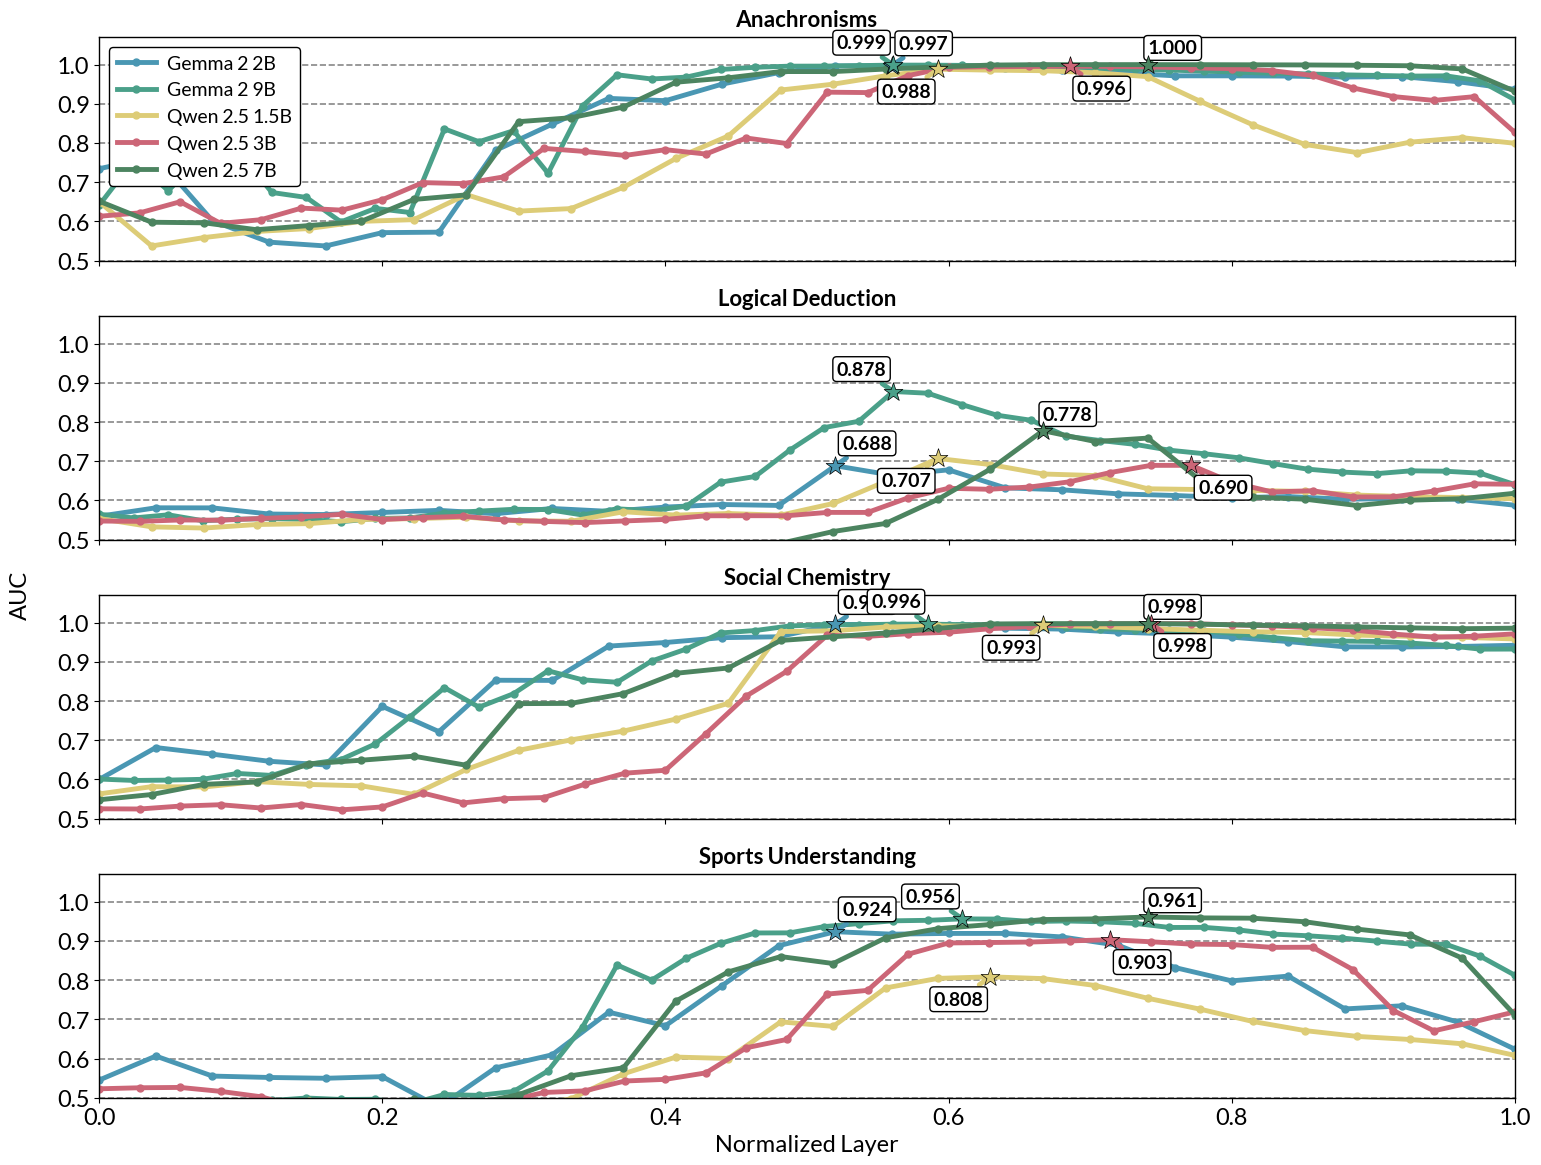

In [30]:
# AUC by Layer Visualization - Dataset by Model (Stacked)
print('Creating AUC by layer plots for each dataset (stacked)...')

# Set mathtext to use a fallback font for math symbols while keeping Lato font
plt.rcParams['mathtext.default'] = 'regular'  # Use regular text style for math
plt.rcParams['mathtext.fontset'] = 'dejavusans'  # Use DejaVu for math symbols

# Set up the soft color palette for models
soft_colors = [
    COLORS['soft-blue'],    # "#4a97b3"
    COLORS['soft-teal'],    # "#4aa089" 
    COLORS['soft-yellow'],  # "#DDCC77"
    COLORS['soft-red'],     # "#CC6677"
    COLORS['soft-green'],   # "#4c8460"
]

# Create figure with 4x1 stacked subplots for the 4 datasets
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.subplots_adjust(hspace=0.1)

for dataset_idx, dataset in enumerate(DATASETS):
    ax = axes[dataset_idx]
    
    # Track whether we plotted any data for this dataset
    plotted_any = False
    
    # Track max points for annotations
    max_points = []
    
    for model_idx, model in enumerate(MODELS):
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores and isinstance(auc_scores, list) and len(auc_scores) > 0:
            # Normalize x-axis to 0-1
            num_layers = len(auc_scores)
            x_normalized = np.linspace(0, 1, num_layers)
            
            # Get model display name and color
            model_display = get_model_display(model)
            color = soft_colors[model_idx % len(soft_colors)]
            
            # Plot the AUC scores with small circular markers for every point
            ax.plot(x_normalized, auc_scores, 
                   color=color, linewidth=3.5, alpha=1.0,  # Increased from 3 to 3.5
                   marker='o', markersize=5, markerfacecolor=color, markeredgecolor=color,  # Increased from 4 to 5
                   label=model_display)
            
            # Find max AUC and its position (earliest if tie)
            max_auc = max(auc_scores)
            max_idx = auc_scores.index(max_auc)  # Gets first occurrence (earliest)
            max_x = x_normalized[max_idx]
            max_y = max_auc
            
            # Store max point info for annotation
            max_points.append({
                'x': max_x,
                'y': max_y,
                'auc': max_auc,
                'model_idx': model_idx,
                'color': color,
                'model': model_display
            })
            
            plotted_any = True
    
    # Add annotations for max AUC points with directional arrows
    if plotted_any and max_points:
        # Define annotation directions to avoid collisions
        directions = [
            {'xytext': (5, 10), 'ha': 'left', 'va': 'bottom'},      # upper right
            {'xytext': (-5, 10), 'ha': 'right', 'va': 'bottom'},    # upper left
            {'xytext': (-5, -10), 'ha': 'right', 'va': 'top'},      # lower left
            {'xytext': (5, -10), 'ha': 'left', 'va': 'top'},        # lower right
            {'xytext': (0, 12), 'ha': 'left', 'va': 'center'},       # right
        ]
        
        for point in max_points:
            direction = directions[point['model_idx'] % len(directions)]
            
            # Add star marker at max point
            ax.scatter(point['x'], point['y'], marker='*', s=200,  # Increased from 150 to 200
                      color=point['color'], edgecolor='black', linewidth=0.5, zorder=10)
            
            # Format AUC score to 3 decimal places
            auc_text = f"{point['auc']:.3f}"
            
            ax.annotate(auc_text,
                       xy=(point['x'], point['y']),
                       xytext=direction['xytext'],
                       textcoords='offset points',
                       ha=direction['ha'], va=direction['va'],
                       fontsize=14, color='black', fontweight='bold',  # Increased from 12 to 14
                       arrowprops=dict(arrowstyle='-', color=point['color'], 
                                     linewidth=3.5, alpha=1.0),  # Increased from 3 to 3.5
                       bbox=dict(boxstyle="round,pad=0.2", facecolor='white', 
                               edgecolor='black', alpha=1.0, linewidth=1),
                       )
    
    # Format the subplot
    if plotted_any:
        ax.set_title(get_dataset_display(dataset), fontsize=16, fontweight='bold', color='black', pad=8)  # Increased from 14 to 16
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1.07)
        
        # Format ticks to match steering plot style
        ax.set_xticks(np.linspace(0, 1, 6))
        ax.set_yticks(np.arange(0.5, 1.07, 0.1))
        ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0.5, 1.07, 0.1)], fontsize=17, color='black')  # Increased from 15 to 17
        
        # Only show x-tick labels on the bottom plot
        if dataset_idx == len(DATASETS) - 1:
            ax.set_xlabel('Normalized Layer', fontsize=17, color='black')  # Increased from 15 to 17
            ax.set_xticklabels([f'{t:.1f}' for t in np.linspace(0, 1, 6)], fontsize=17, color='black')  # Increased from 15 to 17
        else:
            ax.set_xticklabels([])
        
        # Grid and spines - match steering plot exactly
        ax.grid(True, axis='y', alpha=1.0, linestyle='--', linewidth=1.2, color='#888888')
        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

        ax.spines['top'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')

        ax.spines['top'].set_linewidth(1.0)
        ax.spines['right'].set_linewidth(1.0)
        ax.spines['bottom'].set_linewidth(1.0)
        ax.spines['left'].set_linewidth(1.0)
        
        # Add vertically stacked legend only to the top subplot
        if dataset_idx == 0:
            legend = ax.legend(loc='upper left', frameon=True, fontsize=14, handletextpad=0.6,  # Increased from 12 to 14
                             facecolor='white', edgecolor='black', framealpha=1.0,
                             shadow=False, fancybox=True)
    else:
        ax.text(0.5, 0.5, 'No AUC data available', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=16, color='gray')  # Increased from 14 to 16
        ax.set_title(get_dataset_display(dataset), fontsize=16, fontweight='bold', color='black', pad=8)  # Increased from 14 to 16
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1.1)

# Add single shared y-axis label
fig.text(0.04, 0.5, 'AUC', va='center', rotation='vertical', fontsize=17, fontweight='normal', color='black')  # Increased from 15 to 17

# Adjust layout for better spacing
plt.tight_layout(rect=[0.06, 0.02, 1, 1.0])

# Save the figure
outdir = Path('figs/probe-by-layer')
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / 'auc_by_layer_datasets_stacked.png'
fig.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved stacked AUC by layer figure: {save_path}")

plt.show()

In [31]:
import json
from collections import defaultdict
from pathlib import Path

def load_rollout_classifications(cache_dir="darius_cache/rollout_classification"):
    """Load all rollout classification results from JSONL files."""
    cache_path = Path(cache_dir)
    if not cache_path.exists():
        print(f"Rollout classification cache not found at {cache_path}")
        return {}
    
    # Use defaultdict with list factory
    results = defaultdict(list)
    
    for model_dir in cache_path.iterdir():
        if not model_dir.is_dir():
            continue
        model_name = model_dir.name
        
        for dataset_dir in model_dir.iterdir():
            if not dataset_dir.is_dir():
                continue
            dataset_name = dataset_dir.name
            
            # Find all JSONL files
            for jsonl_file in dataset_dir.rglob("*.jsonl"):
                with open(jsonl_file, 'r') as f:
                    for line in f:
                        try:
                            data = json.loads(line)
                            # Group by alpha_abs and direction
                            alpha_abs = data.get('alpha_abs', 0)
                            direction = data.get('direction', 'unknown')
                            
                            # Extract classification results and error types
                            classification = data.get('classification', {})
                            
                            # Add relevant fields for analysis
                            result = {
                                'alpha': data.get('alpha'),
                                'alpha_abs': alpha_abs,
                                'direction': direction,
                                'success': data.get('success', False),
                                'confabulation': data.get('confabulation', False),
                                'non_entailment': data.get('non_entailment', False),
                                'hallucination': data.get('hallucination', False),
                                'sound': data.get('sound', False),
                                'refuse_flag': data.get('refuse_flag', False),
                                'model': model_name,
                                'dataset': dataset_name
                            }
                            
                            # Also include classification details if available
                            if classification:
                                result['follows_from_premises'] = classification.get('follows_from_premises', False)
                                result['refuse'] = classification.get('refuse', False)
                                result['premise_truth_values'] = classification.get('premise_truth_values', [])
                                result['num_premises'] = len(classification.get('premises', []))
                                result['has_false_premises'] = any(not v for v in classification.get('premise_truth_values', []))
                            
                            key = (model_name, dataset_name, alpha_abs, direction)
                            results[key].append(result)
                        except json.JSONDecodeError:
                            continue
    
    return dict(results)

def wilson_score_interval(successes, n, confidence=0.95):
    """
    Calculate Wilson score confidence interval for a binomial proportion.
    
    Args:
        successes: Number of successes
        n: Total number of trials
        confidence: Confidence level (default 0.95 for 95% CI)
    
    Returns:
        (lower_bound, upper_bound, half_width)
    """
    if n == 0:
        return 0, 0, 0
    
    from scipy import stats
    
    # Calculate the proportion
    p_hat = successes / n
    
    # Get z-score for confidence level
    z = stats.norm.ppf((1 + confidence) / 2)
    
    # Wilson score interval formula
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    
    lower = max(0, center - margin)
    upper = min(1, center + margin)
    
    # Return bounds and half-width for error bars
    half_width = (upper - lower) / 2
    
    return lower, upper, half_width

def calculate_classification_metrics(classifications):
    """Calculate metrics from classification results with Wilson score confidence intervals."""
    if not classifications:
        return {}
    
    total = len(classifications)
    
    # Count occurrences
    counts = {
        'confabulation': sum(1 for c in classifications if c.get('confabulation', False)),
        'non_entailment': sum(1 for c in classifications if c.get('non_entailment', False)),
        'hallucination': sum(1 for c in classifications if c.get('hallucination', False)),
        'sound': sum(1 for c in classifications if c.get('sound', False)),
        'refuse': sum(1 for c in classifications if c.get('refuse_flag', False)),
        'follows_from_premises': sum(1 for c in classifications if c.get('follows_from_premises', False)),
        'has_false_premises': sum(1 for c in classifications if c.get('has_false_premises', False)),
    }
    
    metrics = {'total': total}
    
    # Calculate rates and Wilson score confidence intervals
    for metric_name, count in counts.items():
        rate = count / total if total > 0 else 0
        _, _, ci_half_width = wilson_score_interval(count, total)
        
        metrics[f'{metric_name}_rate'] = rate
        metrics[f'{metric_name}_ci'] = ci_half_width
    
    return metrics

### Data Loading for Rollout Classification

# Rollout Classification Visualization Section

### Load and Process Rollout Classification Data

In [32]:
# Load all rollout classification results
rollout_data = load_rollout_classifications()

print(f"Loaded {len(rollout_data)} unique (model, dataset, alpha, direction) combinations")
print(f"Total samples: {sum(len(v) for v in rollout_data.values())}")

# Sample output to understand the data
if rollout_data:
    sample_key = list(rollout_data.keys())[0]
    print(f"\nSample key: {sample_key}")
    print(f"Number of classifications: {len(rollout_data[sample_key])}")
    if rollout_data[sample_key]:
        print(f"Sample classification: {rollout_data[sample_key][0]}")

Loaded 464 unique (model, dataset, alpha, direction) combinations
Total samples: 13684

Sample key: ('Qwen_Qwen2.5-1.5B-Instruct', 'sports_understanding', 12.0, 'no')
Number of classifications: 50
Sample classification: {'alpha': -12.0, 'alpha_abs': 12.0, 'direction': 'no', 'success': True, 'confabulation': True, 'non_entailment': False, 'hallucination': False, 'sound': False, 'refuse_flag': False, 'model': 'Qwen_Qwen2.5-1.5B-Instruct', 'dataset': 'sports_understanding', 'follows_from_premises': True, 'refuse': False, 'premise_truth_values': [False, True, False, False, False], 'num_premises': 5, 'has_false_premises': True}


### Rollout Classification Visualization - Grid Plot

Saved confabulation, non-entailment, and hallucination grid figure with error bars: figs/rollout_classification/confabulation_nonentailment_hallucination_grid.png


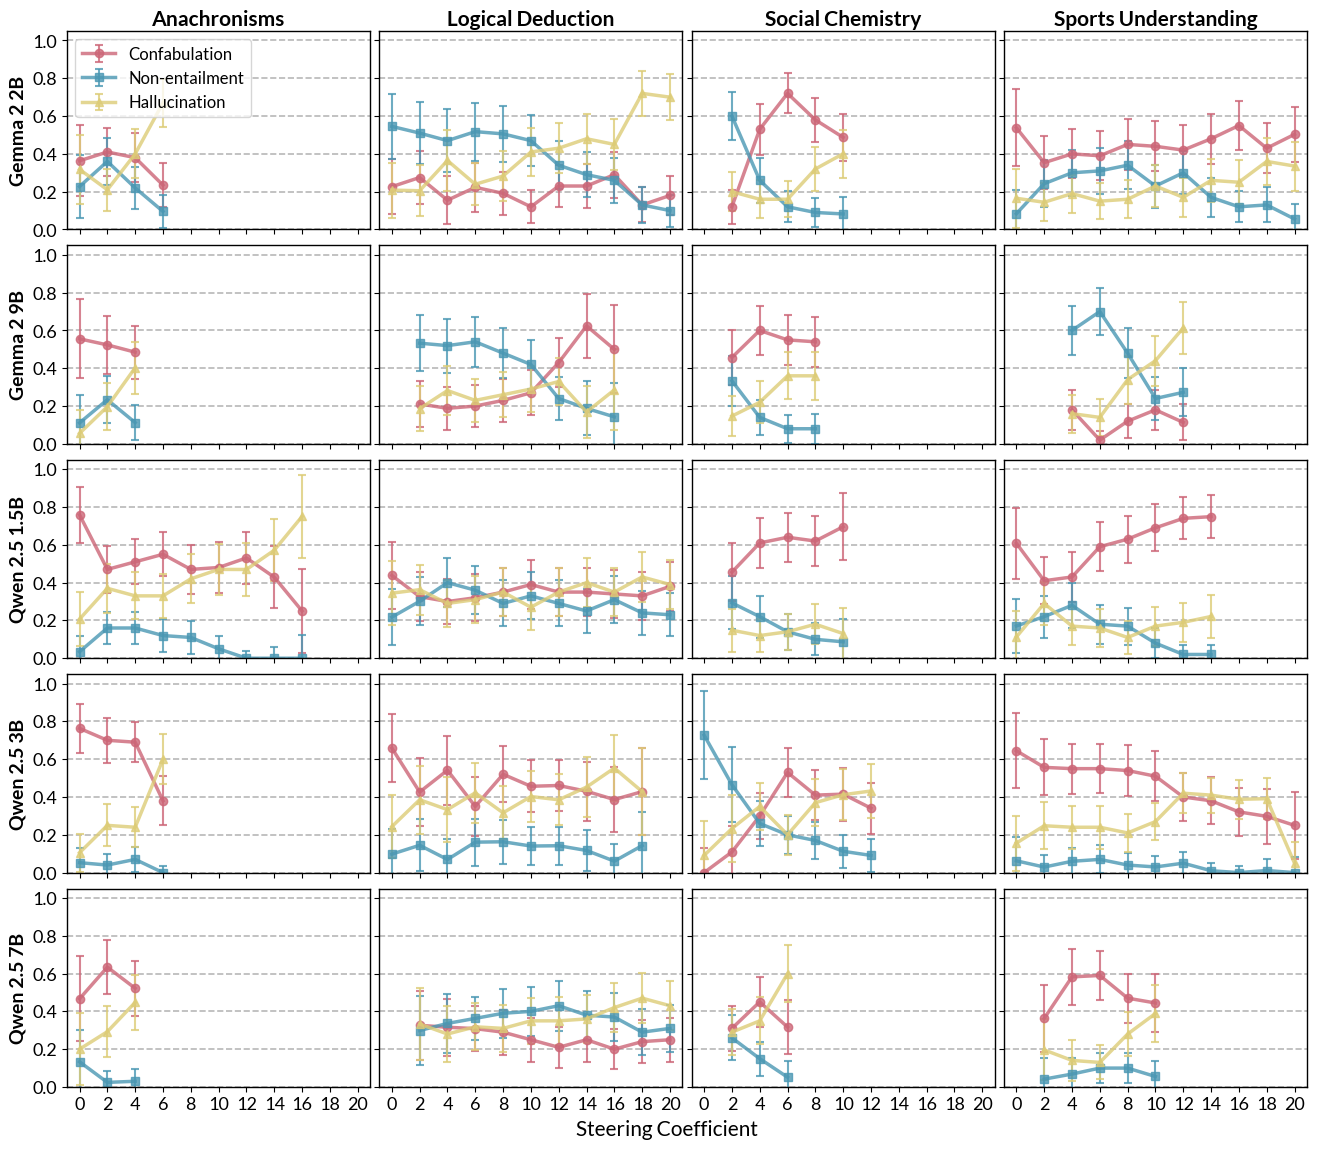

In [33]:
# Create grid plot for confabulation, non-entailment, and hallucination frequencies with error bars
fig, axes = plt.subplots(5, 4, figsize=(16, 12), sharex=True, sharey=False)
fig.subplots_adjust(hspace=0.08, wspace=0.03, top=0.93, bottom=0.05)

# Colors for different metrics
metric_colors = {
    'confabulation': COLORS['soft-red'],
    'non_entailment': COLORS['soft-blue'],
    'hallucination': COLORS['soft-yellow'],  # Adding hallucination with yellow color
    'sound': COLORS['soft-green'],
}

# Process each model and dataset
for model_idx, model in enumerate(MODELS):
    for dataset_idx, dataset in enumerate(DATASETS):
        ax = axes[model_idx, dataset_idx]
        ax.set_aspect('auto')
        
        # Collect data for this model-dataset combination
        yes_metrics = {}
        no_metrics = {}
        
        # Get all alphas for this model-dataset
        for (m, d, alpha_abs, direction), classifications in rollout_data.items():
            # Handle model name variations (with underscore or slash)
            model_normalized = model.replace("/", "_")
            if m == model_normalized or m.replace("_", "/") == model:
                if d == dataset:
                    metrics = calculate_classification_metrics(classifications)
                    if metrics['total'] >= 10:  # Only include if we have enough samples
                        if direction == 'yes':
                            yes_metrics[alpha_abs] = metrics
                        elif direction == 'no':
                            no_metrics[alpha_abs] = metrics
        
        if yes_metrics or no_metrics:
            # Fixed alpha grid from 0 to 20 in steps of 2
            fixed_alphas = np.arange(0, 21, 2)
            
            # Prepare data for plotting with error bars
            confabulation_rates = []
            confabulation_errors = []
            non_entailment_rates = []
            non_entailment_errors = []
            hallucination_rates = []
            hallucination_errors = []
            
            for alpha in fixed_alphas:
                # Collect data from both directions
                confab_values = []
                confab_cis = []
                non_ent_values = []
                non_ent_cis = []
                hall_values = []
                hall_cis = []
                
                if alpha in yes_metrics:
                    confab_values.append(yes_metrics[alpha]['confabulation_rate'])
                    confab_cis.append(yes_metrics[alpha]['confabulation_ci'])
                    non_ent_values.append(yes_metrics[alpha]['non_entailment_rate'])
                    non_ent_cis.append(yes_metrics[alpha]['non_entailment_ci'])
                    hall_values.append(yes_metrics[alpha]['hallucination_rate'])
                    hall_cis.append(yes_metrics[alpha]['hallucination_ci'])
                if alpha in no_metrics:
                    confab_values.append(no_metrics[alpha]['confabulation_rate'])
                    confab_cis.append(no_metrics[alpha]['confabulation_ci'])
                    non_ent_values.append(no_metrics[alpha]['non_entailment_rate'])
                    non_ent_cis.append(no_metrics[alpha]['non_entailment_ci'])
                    hall_values.append(no_metrics[alpha]['hallucination_rate'])
                    hall_cis.append(no_metrics[alpha]['hallucination_ci'])
                
                # Calculate mean and combined error
                if confab_values:
                    confabulation_rates.append(np.mean(confab_values))
                    confabulation_errors.append(np.mean(confab_cis))
                    non_entailment_rates.append(np.mean(non_ent_values))
                    non_entailment_errors.append(np.mean(non_ent_cis))
                    hallucination_rates.append(np.mean(hall_values))
                    hallucination_errors.append(np.mean(hall_cis))
                else:
                    confabulation_rates.append(np.nan)
                    confabulation_errors.append(0)
                    non_entailment_rates.append(np.nan)
                    non_entailment_errors.append(0)
                    hallucination_rates.append(np.nan)
                    hallucination_errors.append(0)
            
            # Plot the metrics as lines with error bars
            x = fixed_alphas.astype(float)
            
            # Plot confabulation rate with error bars
            ax.errorbar(x, confabulation_rates, yerr=confabulation_errors,
                       color=metric_colors['confabulation'], 
                       linewidth=2.5, marker='o', markersize=6,  # Increased from 5 to 6
                       label='Confabulation', alpha=0.8,
                       capsize=3, capthick=1.5, elinewidth=1.5)
            
            # Plot non-entailment rate with error bars
            ax.errorbar(x, non_entailment_rates, yerr=non_entailment_errors,
                       color=metric_colors['non_entailment'], 
                       linewidth=2.5, marker='s', markersize=6,  # Increased from 5 to 6
                       label='Non-entailment', alpha=0.8,
                       capsize=3, capthick=1.5, elinewidth=1.5)
            
            # Plot hallucination rate with error bars
            ax.errorbar(x, hallucination_rates, yerr=hallucination_errors,
                       color=metric_colors['hallucination'], 
                       linewidth=2.5, marker='^', markersize=6,  # Increased from 5 to 6
                       label='Hallucination', alpha=0.8,
                       capsize=3, capthick=1.5, elinewidth=1.5)
            
            # Format axes
            ax.set_xlim(-0.9, 20.9)
            ax.set_xticks(np.arange(0, 21, 2))
            ax.set_ylim(0, 1.05)
            ax.set_yticks(np.arange(0, 1.1, 0.2))
            
            # Grid
            ax.grid(True, axis='y', alpha=0.6, linestyle='--', linewidth=1.2, color='#888888')
            ax.set_axisbelow(True)
            
            # Spines
            for spine in ['top', 'right', 'bottom', 'left']:
                ax.spines[spine].set_visible(True)
                ax.spines[spine].set_color('black')
                ax.spines[spine].set_linewidth(1.0)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=13, color='gray')  # Increased from 11 to 13
            ax.set_xlim(0, 20)
            ax.set_ylim(0, 1)
        
        # Labels and titles
        if model_idx == 0:
            ax.set_title(get_dataset_display(dataset), fontsize=15, fontweight='bold', pad=4)  # Increased from 13 to 15
        
        if dataset_idx == 0:
            ax.set_ylabel(get_model_display(model), fontsize=14, fontweight='bold')  # Increased from 12 to 14
            ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], fontsize=13)  # Increased from 11 to 13
        else:
            ax.set_yticklabels([])
        
        if model_idx == 4:
            ax.tick_params(axis='x', labelsize=13)  # Increased from 11 to 13
        
        # Add legend to first plot
        if model_idx == 0 and dataset_idx == 0:
            ax.legend(loc='upper left', fontsize=12, frameon=True)  # Increased from 10 to 12

# Add single centered x-axis label
fig.text(0.5, 0.01, 'Steering Coefficient', ha='center', fontsize=15)  # Increased from 13 to 15

# Save the figure
outdir = Path('figs/rollout_classification')
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / 'confabulation_nonentailment_hallucination_grid.png'
fig.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved confabulation, non-entailment, and hallucination grid figure with error bars: {save_path}")

plt.show()

### Summary Statistics for Rollout Classification

In [34]:
# Create summary statistics for rollout classification with confabulation and non-entailment
summary_stats = []

for (model, dataset, alpha_abs, direction), classifications in rollout_data.items():
    if classifications:
        metrics = calculate_classification_metrics(classifications)
        
        summary_stats.append({
            'Model': model.split('_')[-1] if '_' in model else model.split('/')[-1],
            'Dataset': dataset,
            'Alpha': alpha_abs,
            'Direction': direction,
            'N': metrics['total'],
            'Confabulation (%)': f"{metrics['confabulation_rate']*100:.1f}",
            'Non-entailment (%)': f"{metrics['non_entailment_rate']*100:.1f}",
            'Sound (%)': f"{metrics['sound_rate']*100:.1f}",
            'Hallucination (%)': f"{metrics['hallucination_rate']*100:.1f}",
            'False Premise (%)': f"{metrics['has_false_premises_rate']*100:.1f}",
            'Refuse (%)': f"{metrics['refuse_rate']*100:.1f}"
        })

if summary_stats:
    summary_df = pd.DataFrame(summary_stats)
    summary_df = summary_df.sort_values(['Model', 'Dataset', 'Alpha', 'Direction'])
    
    # Display summary for each model-dataset combination
    for model in summary_df['Model'].unique():
        model_data = summary_df[summary_df['Model'] == model]
        for dataset in model_data['Dataset'].unique():
            dataset_data = model_data[model_data['Dataset'] == dataset]
            dataset_data = dataset_data[dataset_data["Direction"] == "no"]
            dataset_data = dataset_data[dataset_data["N"] > 10]
            dataset_data["Confabulation Relative"] = (dataset_data["Confabulation (%)"].astype(float) / (dataset_data["Confabulation (%)"].astype(float) + dataset_data["Non-entailment (%)"].astype(float))).round(3) * 100
            dataset_data["Non-entailment Relative"] = (dataset_data["Non-entailment (%)"].astype(float) / (dataset_data["Confabulation (%)"].astype(float) + dataset_data["Non-entailment (%)"].astype(float)  )).round(3) * 100
            if not dataset_data.empty:
                print(f"\n{model} - {get_dataset_display(dataset)}")
                print("="*80)
                print(dataset_data.to_string(index=False))
                print()
    
    # Save full summary to CSV
    summary_path = Path('figs/rollout_classification/confabulation_summary_stats.csv')
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_path, index=False)
    print(f"\nSaved summary statistics to: {summary_path}")


DeepSeek-R1-Distill-Qwen-1.5B - Logical Deduction
                        Model           Dataset  Alpha Direction  N Confabulation (%) Non-entailment (%) Sound (%) Hallucination (%) False Premise (%) Refuse (%)  Confabulation Relative  Non-entailment Relative
DeepSeek-R1-Distill-Qwen-1.5B logical_deduction    0.0        no 25               0.0              100.0       0.0               0.0               0.0      100.0                     0.0                    100.0


DeepSeek-R1-Distill-Qwen-1.5B - Sports Understanding
                        Model              Dataset  Alpha Direction  N Confabulation (%) Non-entailment (%) Sound (%) Hallucination (%) False Premise (%) Refuse (%)  Confabulation Relative  Non-entailment Relative
DeepSeek-R1-Distill-Qwen-1.5B sports_understanding    0.0        no 28               0.0              100.0       0.0               0.0               0.0      100.0                     0.0                    100.0
DeepSeek-R1-Distill-Qwen-1.5B sports_underst